# Simulación de Monte Carlo
En este notebook implementaremos diversas simulaciones de Monte Carlo utilizando diferentes modelos.

## Movimiento Browniano Geométrico (GBM)
El modelo más sencillo que consideraremos es el movimiento browniano geométrico o GBM. Este modelo se define por la ecuación diferencial estocástica siguiente:
$$dS_t = S_t \mu dt +  S_t \sigma dB_t.$$

Discretizando esta expresión para tiempos $t_0, t_1, ..., t_N$, obtenimos la relación recursiva
$$ S_{t_{k+1}} = S_{t_k} + S_{t_k} \mu \Delta t + S_{t_{k}} \sigma \sqrt{\Delta t} Z,$$
dónde $ Z \sim N(0,1)$.

Más adelante ajustaremos los parámetros del modelo a un conjunto de datos, pero de momento realizamos una simulación con parámetros ad hoc.

In [26]:
import SimulacionMonteCarlo 
# import importlib
# importlib.reload(SimulacionMonteCarlo)

In [27]:
param_dict={'Deltat': 0.1, 'N':1000, 'mu':0.1, 'sigma':0.2, 'S0':1, 'M':1000}
gbm = SimulacionMonteCarlo.GBM(param_dict)
gbm.mostrar_parametros()

{'Deltat': 0.1, 'N': 1000, 'mu': 0.1, 'sigma': 0.2, 'S0': 1, 'M': 1000, 'T': 100.0}


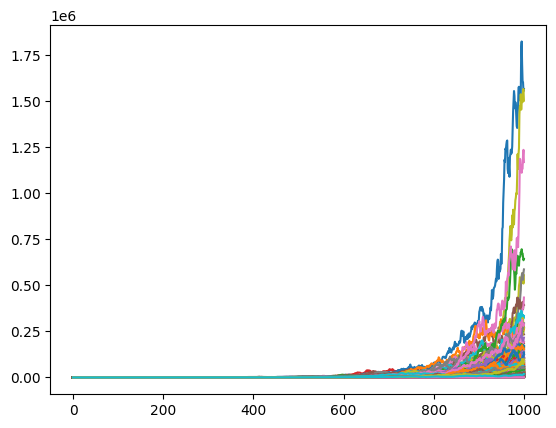

In [29]:
import pandas as pd
pd.DataFrame(gbm.simular()).plot(legend=False)
plt.show()

### Ajuste de parámetros por máxima verosimilitud
Con tal de generar simulaciones más realistas, introducimos un método de ajuste de parámetros. El método ```ajustar_parametros``` tomará como entrada una serie temporal y el número de simulaciones que queremos hacer posteriormente. 

El método de ajuste de los parámetros se basa en la propiedad de Márkov de la serie temporal y en la función de verosimilitud de esa misma serie. La propiedad de Márkov consiste en, enunciada brevemente, que la última variable aleatoria de la serie contiene toda la información de las variables anteriores, por lo que condicionar a esta última variable es equivalente a condicionar a todas las anteriores. Es decir, si $A$ es un subconjunto (Borel mesurable) de $\mathbb{R}$, entonces
$$ P(S_{t_{n+1}} \in A | S_{t_n}, ..., S_{t_0}) = P(S_{t_{n+1}} \in A | S_{t_n}).$$

Esta propiedad nos resulta importante en nuestro contexto porque nos permite escribir la función de verosimilitud de una forma tratable analíticamente. En nuestro caso, la función de verosimilitud es de la forma $f(\mu, \sigma; \textbf{S})$. Tomamos logarítmos sobre esta y aplicamos la propiedad de Márkov para obtener
$$\log f(\mu, \sigma; \textbf{S}) = \sum_{k=1}^N \log f(\mu, \sigma; S_{t_k}| S_{t_{k-1}},...,S_{t_0}) = \sum_{k=1}^N \log f(\mu, \sigma; S_{t_k}| S_{t_{k-1}}).$$

Finalmente, para obtener la función explícita de la verosimilitud, solo hace falta observar la función recursiva de $S_{t_{k+1}}$ en términos de $S_{t_k}$, con lo que se obtiene que
$$ S_{t_{k+1}}|S_{t_k} \sim N( S_{t_k}(1+\mu \Delta t), \sigma^2\Delta t S_{t_k}^2).$$

In [31]:
import datos
# importlib.reload(datos)
ts = datos.download_stock_data('AAPL')['close']

In [32]:
# importlib.reload(SimulacionMonteCarlo)
gbm2 = SimulacionMonteCarlo.GBM()
gbm2.ajustar_parametros(ts, 1000)

/home/jordi/Documents/educacio/master_unir/practicas/codigo/SimulacionMonteCarlo.py:103: RuntimeWarning: invalid value encountered in log
  nlL = -np.sum([np.log(1/(np.sqrt(2*np.pi*new_params['Deltat'])*var_sigma))


Ajuste de parámetros realizado correctamente.


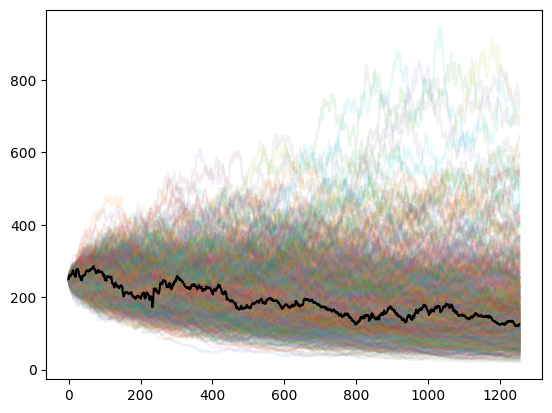

In [33]:
import matplotlib.pyplot as plt
sim = gbm2.simular()
pd.DataFrame(sim).plot(legend=False, alpha=0.1)
plt.plot(ts, color='black')
plt.show()

In [24]:
gbm2.mostrar_parametros()

{'T': 1255, 'N': 1255, 'Deltat': 1.0, 'S0': np.float64(250.12), 'M': 1000, 'mu': np.float64(-0.000400576965864037), 'sigma': np.float64(0.017230989451776497)}


En el gráfico se puede observar aunque haya cierta varianza en la simulación (no olvidemos que se trata de un modelo probabilístico), las simulaciones se distribuyen entorno a nuestro juego de datos, confirmandonos por lo tanto que el ajuste ha sido efectuado correctamente.

## Modelo Merton Jump-Diffusion
Ahora añadimos a nuestro modelo la capacidad de simular saltos en el valor del activo. Esto lo hacemos añadiendo un nuevo sumando a la ecuación recursiva discretizada:
$$ S_{n+1}= S_n + \mu S_n \Delta t + \sigma S_n \sqrt{\Delta t} Z + Q_n,$$
donde $Q_n$ es una variable aleatoria que recoge la posibilidad y magnitud de un salto. Esta variable aleatoria depende de dos otras variable, llamadas $N_n$ y $p_n$. La primera de estas variables indica cuantos saltos se producen en el intervalo $t\in [t_n, t_{n+1})$ y es una Bernouilli($p$), y la segunda si el salto es hacia arriba o hacia abajo, y es una variable Poisson($\lambda \Delta t$). Estas dos variables son independientes. 


La relación entre $Q_n, N_n$ y $p_n$ es la siguiente: 

$$ Q_n | N_n, p_n = \begin{cases} 0 \quad si \quad N_n = 0 \\ k\cdot N(\eta, \xi^2) \quad si \quad p_n=1\quad y\quad N_n =k \\ -k\cdot N(\eta, \xi^2) \quad si\quad p_n=0\quad y\quad N_n =k
\end{cases}$$



In [7]:
import SimulacionMonteCarlo 
import importlib
importlib.reload(SimulacionMonteCarlo)

<module 'SimulacionMonteCarlo' from '/home/jordi/Documents/educacio/master_unir/practicas/codigo/SimulacionMonteCarlo.py'>

In [9]:
param_dict={'Deltat': 0.1, 'N':1000, 'mu':0.1, 'sigma':0.2, 'S0':1, 'M':1000,
            'p':0.5, 'lambda': 0.1, 'eta':10, 'xi':10 } 
mjd = SimulacionMonteCarlo.MertonJumpDiffusion(param_dict)

{'Deltat': 0.1, 'N': 1000, 'mu': 0.1, 'sigma': 0.2, 'S0': 1, 'M': 1000, 'p': 0.5, 'lambda': 0.1, 'eta': 10, 'xi': 10, 'T': 100.0}


### Ajuste de parámetros
Para realizar el ajuste de parámetros, debemos calcular la función de densidad de la muestra $\textbf{S}$. Esta vez debemos tener en cuenta las variables $Q_n, N_n$ y $p_n$, que actúan como parámetros pero que tienen sus respectivas distribuciones marginales, conjuntas y condicionales. Para tratar la función de versosimilitud nos harán falta suposiciones sobre estas variables. Las iremos introduciendo a lo largo del desarrollo.


Partimos del caso del movimiento browniano geométrico. Con tal de simplificar la notación, sea $\Theta$ el vector de todos los parámetros del modelo: $\mu, \sigma, p, \lambda, \eta$ y $\xi$. 

Debemos hacer un apunte, que es el siguiente. Cuando condicionamos a $S_{k-1}$, estamos asumiendo que conocemos toda la información necesaria para conocer $S_{k-1}$, que es toda la información disponible hasta tiempo $t_{k-1}$. Pues bien, esta información es suficiente para conocer también $Q_{k-1}, N_{k-1}$ y $p_{k-1}$. Denominamos estos valores o esta información por $\mathcal{F}_{k-1}$, entonces tenemos que

$$\log f(\Theta; \textbf{S,Q,p,N}) = \sum_{k=1}^N \log f(\Theta; S_{k},Q_k,p_k,N_k|\mathcal{F}_{k-1} )$$

Ahora consideraremos que el trio de variables $Q_k,p_k$ y $N_k$ y $S_k$ son independientes. Esto es razonable, ya que consideraremos que los saltos pueden darse con probabilidad y magnitud independiente del precio actual del activo. Entonces la función de densidad factoriza y obtenemos que la última expresión es igual a 

$$ \sum_{k=1}^N \log f(\Theta; S_{k} | \mathcal{F}_{k-1} ) + \log f(\Theta; Q_k,p_k,N_k|\mathcal{F}_{k-1} ) $$

Podemos simplificar esta expresión ya que $Q_k, N_k$ y $p_k$ son independientes de la información hasta tiempo $t_{k-1}$, por lo que en el segundo sumando podemos quitar el condicional. Ahora aplicamos la relación entre $Q_k, N_k$ y $p_k$. tenemos

$$ \sum_{k=1}^N \log f(\Theta; Q_k,p_k,N_k) = \sum_{k=1}^N \log f(\Theta; Q_k|p_k,N_k ) + \log f(\Theta; p_k ) + \log f(\Theta; N_k ),$$

donde al final hemos usado que $p_k$ y $N_k$ son independientes para separa su verosimilitud conjunta.

En resumen, la función de verosimilitud es la siguiente:
$$\log f(\Theta; \textbf{S,Q,p,N}) = \sum_{k=1}^N \log f(\Theta; S_{k} | \mathcal{F}_{k-1} ) + \log f(\Theta; Q_k|p_k,N_k ) + \log f(\Theta; p_k ) + \log f(\Theta; N_k )$$

(En realidad la información de $\mathcal{F}_{k}$ esta recogida íntegramente en $S_k$ y $Q_k$, por lo que esto se puede simplificar un poco.)